In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [34]:

# 1. Read the data from the Excel file
df = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Data Science Project/Projects/behavior_analytics_output 2.csv")

# 2. Save it cleanly as a CSV file
df.to_csv("behavior_analytics_output.csv", index=False)

In [35]:
df.head()

,Client_ID,Timestamp,Behavior_Name,Behavior_Type,Measurement_Count,Setting
0,Client_0881,2026-08-01 00:00:00,Task Completion,Accel,3,Community
1,Client_0492,2026-08-01 01:00:00,Task Completion,Decel,3,Center
2,Client_0881,2026-08-01 02:00:00,Task Completion,Accel,3,Home
3,Client_0881,2026-08-01 03:00:00,Vocal Manding,Decel,4,Center
4,Client_0492,2026-08-01 04:00:00,Vocal Manding,Decel,7,Community


In [36]:
df.tail()

,Client_ID,Timestamp,Behavior_Name,Behavior_Type,Measurement_Count,Setting
95,Client_0492,2026-08-04 23:00:00,Elopement,Accel,1,Center
96,Client_0492,2026-08-05 00:00:00,Vocal Manding,Accel,4,Center
97,Client_0881,2026-08-05 01:00:00,Task Completion,Accel,5,Home
98,Client_0492,2026-08-05 02:00:00,Elopement,Accel,7,Community
99,Client_0492,2026-08-05 03:00:00,Vocal Manding,Accel,1,Center


In [37]:
df.describe()

,Timestamp,Measurement_Count
count,100,100.000000
mean,2026-08-03 01:30:00.000000256,4.630000
min,2026-08-01 00:00:00,1.000000
25%,2026-08-02 00:45:00,3.000000
50%,2026-08-03 01:30:00,4.000000
75%,2026-08-04 02:15:00,7.000000
max,2026-08-05 03:00:00,9.000000
std,NaN,2.661567


In [38]:
df.isnull().sum()

,0
Client_ID,0
Timestamp,0
Behavior_Name,0
Behavior_Type,0
Measurement_Count,0
Setting,0


In [39]:
num_unique_clients = df['Client_ID'].nunique()
print(f"Number of unique clients in the sample: {num_unique_clients}")

Number of unique clients in the sample: 3


In [40]:
# Check data types
print("Data Types:")
print(df.dtypes)

# Check unique values for categorical columns (example for 'Behavior_Name' and 'Behavior_Type')
print("\nUnique values in 'Behavior_Name':")
print(df['Behavior_Name'].unique())

print("\nUnique values in 'Behavior_Type':")
print(df['Behavior_Type'].unique())

print("\nUnique values in 'Setting':")
print(df['Setting'].unique())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

Data Types:
Client_ID                    object
Timestamp            datetime64[ns]
Behavior_Name                object
Behavior_Type                object
Measurement_Count             int64
Setting                      object
dtype: object

Unique values in 'Behavior_Name':
['Task Completion' 'Vocal Manding' 'Aggression' 'Elopement']

Unique values in 'Behavior_Type':
['Accel' 'Decel']

Unique values in 'Setting':
['Community' 'Center' 'Home']

Number of duplicate rows: 0


In [41]:
mean_measurement_by_behavior = df.groupby('Behavior_Name')['Measurement_Count'].mean().reset_index()
display(mean_measurement_by_behavior)

,Behavior_Name,Measurement_Count
0,Aggression,4.590909
1,Elopement,4.473684
2,Task Completion,4.160000
3,Vocal Manding,5.088235


/tmp/ipykernel_808/1282049400.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Behavior_Name', y='Measurement_Count', data=mean_measurement_by_behavior, palette='viridis')


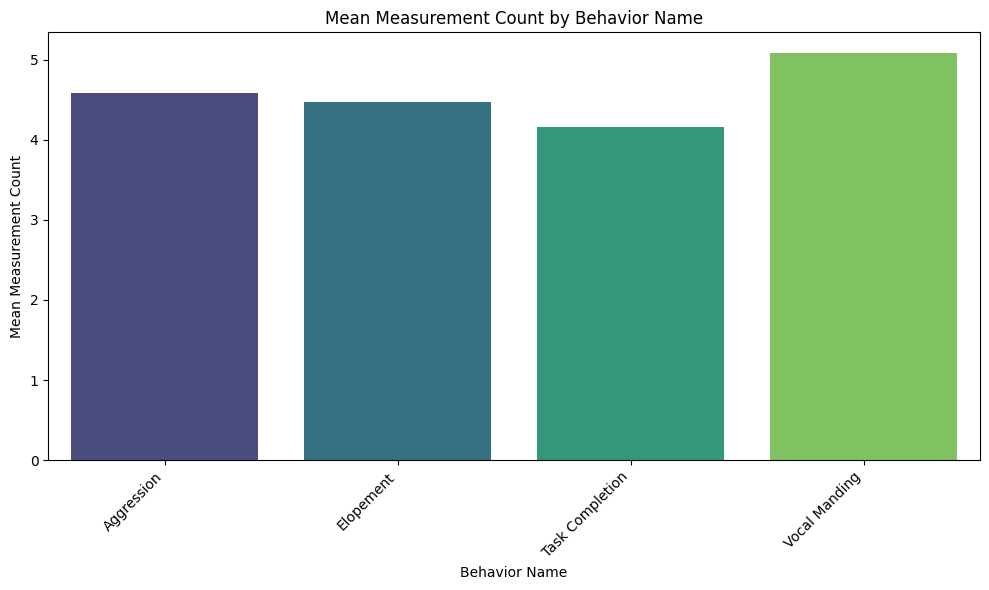

In [42]:


plt.figure(figsize=(10, 6))
sns.barplot(x='Behavior_Name', y='Measurement_Count', data=mean_measurement_by_behavior, palette='viridis')
plt.title('Mean Measurement Count by Behavior Name')
plt.xlabel('Behavior Name')
plt.ylabel('Mean Measurement Count')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [43]:
aggression_data = df[df['Behavior_Name'] == 'Aggression']

aggression_in_home = aggression_data[aggression_data['Setting'] == 'Home'].shape[0]
aggression_in_community = aggression_data[aggression_data['Setting'] == 'Community'].shape[0]

print(f"'Aggression' occurred {aggression_in_home} times in the 'Home' setting.")
print(f"'Aggression' occurred {aggression_in_community} times in the 'Community' setting.")

if aggression_in_home > aggression_in_community:
    print("\n'Aggression' was more likely to occur in the 'Home' setting.")
elif aggression_in_community > aggression_in_home:
    print("\n'Aggression' was more likely to occur in the 'Community' setting.")
else:
    print("\n'Aggression' occurred equally in 'Home' and 'Community' settings.")

'Aggression' occurred 6 times in the 'Home' setting.
'Aggression' occurred 8 times in the 'Community' setting.

'Aggression' was more likely to occur in the 'Community' setting.


In [44]:
aggression_by_client = aggression_data['Client_ID'].value_counts().reset_index()
aggression_by_client.columns = ['Client_ID', 'Aggression_Count']

most_aggressive_client = aggression_by_client.iloc[0]

print("Aggression occurrences by client:")
display(aggression_by_client)

print(f"\nClient {most_aggressive_client['Client_ID']} was most likely to exhibit 'Aggression', with {most_aggressive_client['Aggression_Count']} occurrences.")

Aggression occurrences by client:


,Client_ID,Aggression_Count
0,Client_0881,8
1,Client_1102,8
2,Client_0492,6



Client Client_0881 was most likely to exhibit 'Aggression', with 8 occurrences.


In [45]:
elopement_data = df[df['Behavior_Name'] == 'Elopement']

elopement_by_client = elopement_data['Client_ID'].value_counts().reset_index()
elopement_by_client.columns = ['Client_ID', 'Elopement_Count']

most_elopement_client = elopement_by_client.iloc[0]

print("Elopement occurrences by client:")
display(elopement_by_client)

print(f"\nClient {most_elopement_client['Client_ID']} was most likely to exhibit 'Elopement', with {most_elopement_client['Elopement_Count']} occurrences.")

Elopement occurrences by client:


,Client_ID,Elopement_Count
0,Client_0492,9
1,Client_1102,7
2,Client_0881,3



Client Client_0492 was most likely to exhibit 'Elopement', with 9 occurrences.


In [46]:
vocal_manding_data = df[df['Behavior_Name'] == 'Vocal Manding']

vocal_manding_by_client = vocal_manding_data['Client_ID'].value_counts().reset_index()
vocal_manding_by_client.columns = ['Client_ID', 'Vocal_Manding_Count']

most_vocal_manding_client = vocal_manding_by_client.iloc[0]

print("Vocal Manding occurrences by client:")
display(vocal_manding_by_client)

print(f"\nClient {most_vocal_manding_client['Client_ID']} was most likely to exhibit 'Vocal Manding', with {most_vocal_manding_client['Vocal_Manding_Count']} occurrences.")

Vocal Manding occurrences by client:


,Client_ID,Vocal_Manding_Count
0,Client_1102,13
1,Client_0881,12
2,Client_0492,9



Client Client_1102 was most likely to exhibit 'Vocal Manding', with 13 occurrences.


In [47]:
task_completion_data = df[df['Behavior_Name'] == 'Task Completion']

task_completion_by_client = task_completion_data['Client_ID'].value_counts().reset_index()
task_completion_by_client.columns = ['Client_ID', 'Task_Completion_Count']

most_task_completion_client = task_completion_by_client.iloc[0]

print("Task Completion occurrences by client:")
display(task_completion_by_client)

print(f"\nClient {most_task_completion_client['Client_ID']} was most likely to exhibit 'Task Completion', with {most_task_completion_client['Task_Completion_Count']} occurrences.")

Task Completion occurrences by client:


,Client_ID,Task_Completion_Count
0,Client_0492,9
1,Client_0881,8
2,Client_1102,8



Client Client_0492 was most likely to exhibit 'Task Completion', with 9 occurrences.


In [48]:
behavior_counts_per_client = df.groupby(['Client_ID', 'Behavior_Name']).size().reset_index(name='Count')

# Find the most frequent behavior for each client
most_frequent_behavior_summary = behavior_counts_per_client.loc[behavior_counts_per_client.groupby('Client_ID')['Count'].idxmax()]

print("Summary of Most Frequent Behavior per Client:")
display(most_frequent_behavior_summary.reset_index(drop=True))

Summary of Most Frequent Behavior per Client:


,Client_ID,Behavior_Name,Count
0,Client_0492,Elopement,9
1,Client_0881,Vocal Manding,12
2,Client_1102,Vocal Manding,13


In [49]:
behavior_by_setting = df.groupby(['Setting', 'Behavior_Name']).size().unstack(fill_value=0)

print("Behavior Frequencies Across Settings:")
display(behavior_by_setting)

Behavior Frequencies Across Settings:


Behavior_Name,Aggression,Elopement,Task Completion,Vocal Manding
Setting,,,,
Center,8,8,8,18
Community,8,6,7,11
Home,6,5,10,5


This table shows the count of each behavior (`Aggression`, `Elopement`, `Task Completion`, `Vocal Manding`) within each setting (`Center`, `Community`, `Home`). You can now easily compare how often each behavior occurs in different environments.

In [50]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

First, we need to convert the categorical features (`Setting` and `Behavior_Name`) into numerical labels, as machine learning models work with numbers. `LabelEncoder` will assign a unique integer to each unique category.

In [51]:
# Create LabelEncoders for 'Setting' and 'Behavior_Name'
le_setting = LabelEncoder()
le_behavior = LabelEncoder()

# Apply Label Encoding
df['Setting_Encoded'] = le_setting.fit_transform(df['Setting'])
df['Behavior_Name_Encoded'] = le_behavior.fit_transform(df['Behavior_Name'])

display(df[['Setting', 'Setting_Encoded', 'Behavior_Name', 'Behavior_Name_Encoded']].head())

,Setting,Setting_Encoded,Behavior_Name,Behavior_Name_Encoded
0,Community,1,Task Completion,2
1,Center,0,Task Completion,2
2,Home,2,Task Completion,2
3,Center,0,Vocal Manding,3
4,Community,1,Vocal Manding,3


Now, we'll define our features (X) and target (y). For predicting behavior based on setting, 'Setting_Encoded' will be our feature, and 'Behavior_Name_Encoded' will be our target. We will then split the data into training and testing sets to evaluate the model's performance on unseen data.

In [52]:
# Define features (X) and target (y)
X = df[['Setting_Encoded']]
y = df['Behavior_Name_Encoded']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 70 samples
Testing set size: 30 samples


Using Machine Learning to Analyze Data

Next, we'll train a `RandomForestClassifier`. This model is an ensemble method that works well for classification tasks and can handle the type of data we have. After training, we will make predictions on the test set and evaluate the model's accuracy.

In [53]:
# Initialize and train the RandomForestClassifier model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_behavior.classes_))

Model Accuracy: 0.40

Classification Report:
                 precision    recall  f1-score   support

     Aggression       0.00      0.00      0.00         7
      Elopement       0.00      0.00      0.00         6
Task Completion       0.50      0.29      0.36         7
  Vocal Manding       0.38      1.00      0.56        10

       accuracy                           0.40        30
      macro avg       0.22      0.32      0.23        30
   weighted avg       0.24      0.40      0.27        30



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Now, let's see how we can use our trained model to predict the most likely behavior for a specific setting. For example, let's predict behavior for the 'Home' setting.

In [54]:
# Example: Predict behavior for a new setting, e.g., 'Home'
new_setting = 'Home'

# Encode the new setting
try:
    new_setting_encoded = le_setting.transform([new_setting])[0]
except ValueError:
    print(f"Error: '{new_setting}' is not a known setting. Known settings are: {le_setting.classes_}")
    new_setting_encoded = None

if new_setting_encoded is not None:
    # Reshape for prediction (model expects 2D array)
    prediction_input = [[new_setting_encoded]]

    # Predict the encoded behavior
    predicted_behavior_encoded = model.predict(prediction_input)[0]

    # Decode the predicted behavior back to its original name
    predicted_behavior_name = le_behavior.inverse_transform([predicted_behavior_encoded])[0]

    print(f"For the '{new_setting}' setting, the most likely predicted behavior is: '{predicted_behavior_name}'")

For the 'Home' setting, the most likely predicted behavior is: 'Task Completion'


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


To improve our model, let's include 'Measurement_Count' as an additional feature. This quantitative measure might provide more context for predicting behaviors. We'll update our features (`X`), split the data again, and retrain the `RandomForestClassifier`.

In [55]:
# Define features (X) to include 'Setting_Encoded' and 'Measurement_Count'
X_new = df[['Setting_Encoded', 'Measurement_Count']]
y_new = df['Behavior_Name_Encoded'] # Target remains the same

# Split the data into training and testing sets with the new features
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.3, random_state=42, stratify=y_new)

print(f"New training set size: {X_train_new.shape[0]} samples")
print(f"New testing set size: {X_test_new.shape[0]} samples")

New training set size: 70 samples
New testing set size: 30 samples


In [56]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# First, encode 'Client_ID' as well
le_client = LabelEncoder()
df['Client_ID_Encoded'] = le_client.fit_transform(df['Client_ID'])

display(df[['Client_ID', 'Client_ID_Encoded', 'Setting_Encoded', 'Measurement_Count', 'Behavior_Name_Encoded']].head())

# Redefine features (X) to include 'Setting_Encoded', 'Measurement_Count', and 'Client_ID_Encoded'
X_all_features = df[['Setting_Encoded', 'Measurement_Count', 'Client_ID_Encoded']]
y_all_features = df['Behavior_Name_Encoded'] # Target remains the same

# Split the data into training and testing sets with all features
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all_features, y_all_features, test_size=0.3, random_state=42, stratify=y_all_features)

print(f"Training set size for all features model: {X_train_all.shape[0]} samples")
print(f"Testing set size for all features model: {X_test_all.shape[0]} samples")

# Initialize and train the GradientBoostingClassifier model with all features
# Note: GradientBoostingClassifier does not have a direct 'class_weight' parameter.
model_gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model_gb.fit(X_train_all, y_train_all)

# Make predictions on the test set
y_pred_gb = model_gb.predict(X_test_all)

# Evaluate the Gradient Boosting model
accuracy_gb = accuracy_score(y_test_all, y_pred_gb)
print(f"\nGradient Boosting Model Accuracy (all features): {accuracy_gb:.2f}")
print("\nGradient Boosting Classification Report (all features):")
print(classification_report(y_test_all, y_pred_gb, target_names=le_behavior.classes_))

# Example: Predict behavior for a specific client, setting, and measurement count using the new GB model
new_client = 'Client_0492'
new_setting = 'Home'
new_measurement_count = 5 # Example count

try:
    new_client_encoded = le_client.transform([new_client])[0]
    new_setting_encoded = le_setting.transform([new_setting])[0]
except ValueError as e:
    print(f"Error encoding input: {e}")
    new_client_encoded = None
    new_setting_encoded = None

if new_client_encoded is not None and new_setting_encoded is not None:
    # Create a DataFrame for prediction input with feature names
    prediction_input_all = pd.DataFrame([[new_setting_encoded, new_measurement_count, new_client_encoded]],
                                        columns=['Setting_Encoded', 'Measurement_Count', 'Client_ID_Encoded'])

    predicted_behavior_encoded_gb = model_gb.predict(prediction_input_all)[0]
    predicted_behavior_name_gb = le_behavior.inverse_transform([predicted_behavior_encoded_gb])[0]

    print(f"\nFor Client '{new_client}' in '{new_setting}' setting with Measurement Count '{new_measurement_count}', the predicted behavior (Gradient Boosting) is: '{predicted_behavior_name_gb}'")

,Client_ID,Client_ID_Encoded,Setting_Encoded,Measurement_Count,Behavior_Name_Encoded
0,Client_0881,1,1,3,2
1,Client_0492,0,0,3,2
2,Client_0881,1,2,3,2
3,Client_0881,1,0,4,3
4,Client_0492,0,1,7,3


Training set size for all features model: 70 samples
Testing set size for all features model: 30 samples

Gradient Boosting Model Accuracy (all features): 0.37

Gradient Boosting Classification Report (all features):
                 precision    recall  f1-score   support

     Aggression       0.33      0.29      0.31         7
      Elopement       0.00      0.00      0.00         6
Task Completion       0.27      0.43      0.33         7
  Vocal Manding       0.55      0.60      0.57        10

       accuracy                           0.37        30
      macro avg       0.29      0.33      0.30        30
   weighted avg       0.32      0.37      0.34        30


For Client 'Client_0492' in 'Home' setting with Measurement Count '5', the predicted behavior (Gradient Boosting) is: 'Vocal Manding'


## Feature Engineering: Extracting More Temporal Information

In [59]:
# Extract more time-based features from 'Timestamp'
df['Month'] = df['Timestamp'].dt.month
df['Day_of_Month'] = df['Timestamp'].dt.day
df['Week_of_Year'] = df['Timestamp'].dt.isocalendar().week.astype(int)
df['Day_of_Week_Name'] = df['Timestamp'].dt.day_name()

# Display the updated DataFrame with new temporal columns
display(df[['Timestamp', 'Month', 'Day_of_Month', 'Week_of_Year', 'Day_of_Week_Name']].head())

# Encode 'Day_of_Week_Name' if needed for the model (or use an ordinal encoder)
le_day_of_week = LabelEncoder()
df['Day_of_Week_Encoded'] = le_day_of_week.fit_transform(df['Day_of_Week_Name'])

,Timestamp,Month,Day_of_Month,Week_of_Year,Day_of_Week_Name
0,2026-08-01 00:00:00,8,1,31,Saturday
1,2026-08-01 01:00:00,8,1,31,Saturday
2,2026-08-01 02:00:00,8,1,31,Saturday
3,2026-08-01 03:00:00,8,1,31,Saturday
4,2026-08-01 04:00:00,8,1,31,Saturday


Now, let's redefine our features to include these new temporal insights, along with the existing `Setting_Encoded`, `Measurement_Count`, and `Client_ID_Encoded`. We will then retrain and evaluate the Gradient Boosting Classifier with this more comprehensive set of features.

In [60]:
# Redefine features (X) to include all relevant encoded and engineered features
X_temporal_features = df[['Setting_Encoded', 'Measurement_Count', 'Client_ID_Encoded', 'Month', 'Day_of_Month', 'Week_of_Year', 'Day_of_Week_Encoded']]
y_temporal_features = df['Behavior_Name_Encoded'] # Target remains the same

# Split the data into training and testing sets with the expanded features
X_train_temp, X_test_temp, y_train_temp, y_test_temp = train_test_split(X_temporal_features, y_temporal_features, test_size=0.3, random_state=42, stratify=y_temporal_features)

print(f"Training set size for temporal features model: {X_train_temp.shape[0]} samples")
print(f"Testing set size for temporal features model: {X_test_temp.shape[0]} samples")

# Initialize and train the GradientBoostingClassifier model with expanded features
# Using the same parameters as the previous GB model for fair comparison before tuning
model_gb_temporal = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model_gb_temporal.fit(X_train_temp, y_train_temp)

# Make predictions on the test set
y_pred_gb_temporal = model_gb_temporal.predict(X_test_temp)

# Evaluate the Gradient Boosting model with temporal features
accuracy_gb_temporal = accuracy_score(y_test_temp, y_pred_gb_temporal)
print(f"\nGradient Boosting Model Accuracy (with temporal features): {accuracy_gb_temporal:.2f}")
print("\nGradient Boosting Classification Report (with temporal features):")
print(classification_report(y_test_temp, y_pred_gb_temporal, target_names=le_behavior.classes_))

Training set size for temporal features model: 70 samples
Testing set size for temporal features model: 30 samples

Gradient Boosting Model Accuracy (with temporal features): 0.23

Gradient Boosting Classification Report (with temporal features):
                 precision    recall  f1-score   support

     Aggression       0.00      0.00      0.00         7
      Elopement       0.11      0.17      0.13         6
Task Completion       0.40      0.29      0.33         7
  Vocal Manding       0.40      0.40      0.40        10

       accuracy                           0.23        30
      macro avg       0.23      0.21      0.22        30
   weighted avg       0.25      0.23      0.24        30



## Feature Importance Analysis for Model with Temporal Features

/tmp/ipykernel_808/3442921446.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_temporal, palette='viridis')


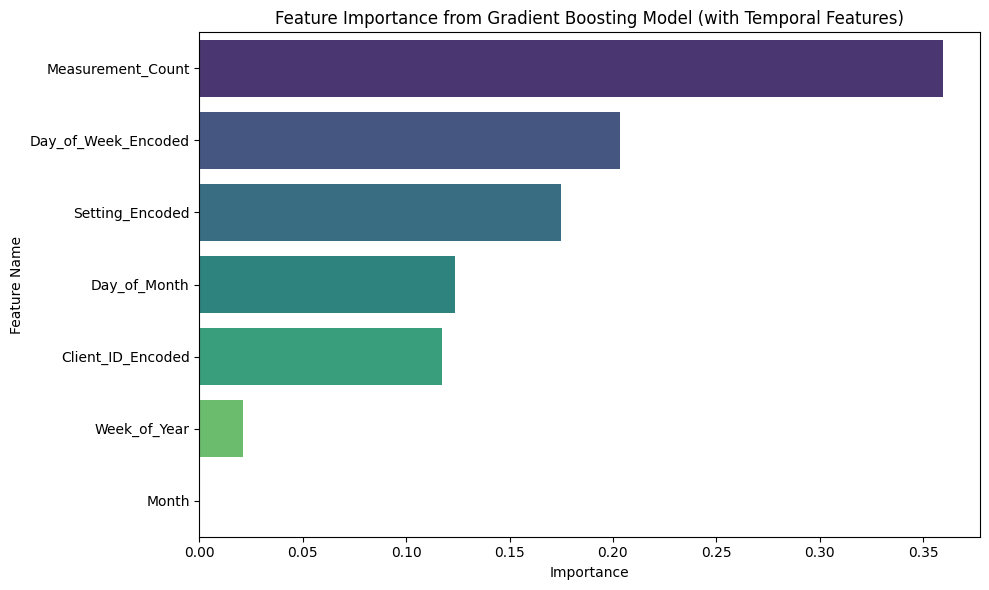

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the model with temporal features
feature_importances_temporal = model_gb_temporal.feature_importances_

# Get feature names from the training data (X_train_temp)
feature_names_temporal = X_train_temp.columns

# Create a DataFrame for better visualization
importance_df_temporal = pd.DataFrame({'Feature': feature_names_temporal, 'Importance': feature_importances_temporal})

# Sort features by importance in descending order
importance_df_temporal = importance_df_temporal.sort_values(by='Importance', ascending=False)

# Plotting feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_temporal, palette='viridis')
plt.title('Feature Importance from Gradient Boosting Model (with Temporal Features)')
plt.xlabel('Importance')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

Overall, the data shows that vocal manding has the highest mean measurement count of 5.09, followed by aggression 4.59, elopement 4.47, and task completion at 4.16.

Aggression was more likely to uccur in the community (8 times) than the home setting (6 times).

Client 'Client_0881' was most likely to exhibit 'Aggression' (8 occurrences).
Elopement:

Client 'Client_0492' was most likely to exhibit 'Elopement' (9 occurrences).

Vocal Manding:
Client 'Client_1102' was most likely to exhibit 'Vocal Manding' (13 occurrences).
Task Completion:

Client 'Client_0492' was most likely to exhibit 'Task Completion' (9 occurrences).
Behavior Frequencies Across Settings:

Center: 'Vocal Manding' (18) is the most frequent behavior.

Community: 'Aggression' (8) is the most frequent behavior, followed by 'Vocal Manding' (11).

Home: 'Task Completion' (10) is the most frequent behavior.


In summary, 'Vocal Manding' tends to have the highest measurement counts and is most frequent in the 'Center' setting. 'Aggression' is more prominent in 'Community' settings, while 'Task Completion' is most common in 'Home' settings.

